In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from scipy import signal
from pathlib import Path
import os

BLUR_IMAGES = [
    '/content/blur1.png',
    '/content/blur2.png',
    '/content/blur3.png',
    '/content/blur4.png',
    '/content/blur5.png',
    '/content/blur6.png'

]

OUTPUT_DIR = Path('/content/task5_gopro_deblurred_wiener')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
def wiener_deblur(img, kernel_size=7, K=0.01, noise_power=0.0001):
    # Convert
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img.copy()


    kernel = np.zeros((kernel_size, kernel_size))
    kernel[int((kernel_size-1)/2), :] = np.ones(kernel_size)
    kernel = kernel / kernel_size


    img_fft = np.fft.fft2(img_gray)
    kernel_fft = np.fft.fft2(kernel, s=img_gray.shape)
    kernel_fft_conj = np.conj(kernel_fft)

    # Wiener filter H(u,v)
    H = kernel_fft * kernel_fft_conj / (np.abs(kernel_fft)**2 + K)

    # Apply filter
    restored_fft = img_fft * H
    restored = np.real(np.fft.ifft2(restored_fft))

    return np.clip(restored, 0, 255).astype(np.uint8)

# Process each image
results = []
for img_path in BLUR_IMAGES:
    img = cv2.imread(img_path)
    deblurred = wiener_deblur(img, kernel_size=9, K=0.05)

    base_name = Path(img_path).stem
    out_path = OUTPUT_DIR / f'{base_name}_wiener.jpg'
    cv2.imwrite(str(out_path), deblurred)

    results.append({
        'original': img_path,
        'deblurred': str(out_path),
        'psnr': 0
    })


In [6]:
!pip install ultralytics pandas numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.0 MB/s eta 0:00:00


In [8]:
from ultralytics import YOLO
import pandas as pd
import numpy as np
import glob

pretrained = YOLO('yolov8n.pt')
custom = YOLO('/content/best.pt')

task5_dir = '/content/task5_gopro'
conditions = ['blur', 'deblurred_wiener', 'sharp']

results = []
for cond in conditions:
    folder = f'{task5_dir}/{cond}'
    # FIXED: JPG + PNG
    paths = glob.glob(f'{folder}/*.png') + glob.glob(f'{folder}/*.jpg')


    # Pretrained
    pretrained_dets = []
    for img in paths:
        r = pretrained.predict(img, conf=0.1, verbose=False)
        pretrained_dets.append(len(r[0].boxes))

    # Custom (lower conf for blurry model)
    custom_dets = []
    for img in paths:
        r = custom.predict(img, conf=0.05, verbose=False)
        custom_dets.append(len(r[0].boxes))

    results.append({
        'condition': cond,
        'n_images': len(paths),
        'pretrained_mean': round(np.mean(pretrained_dets), 2),
        'custom_mean': round(np.mean(custom_dets), 2)
    })

df = pd.DataFrame(results)
df.to_csv('/content/task5_final_results.csv', index=False)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


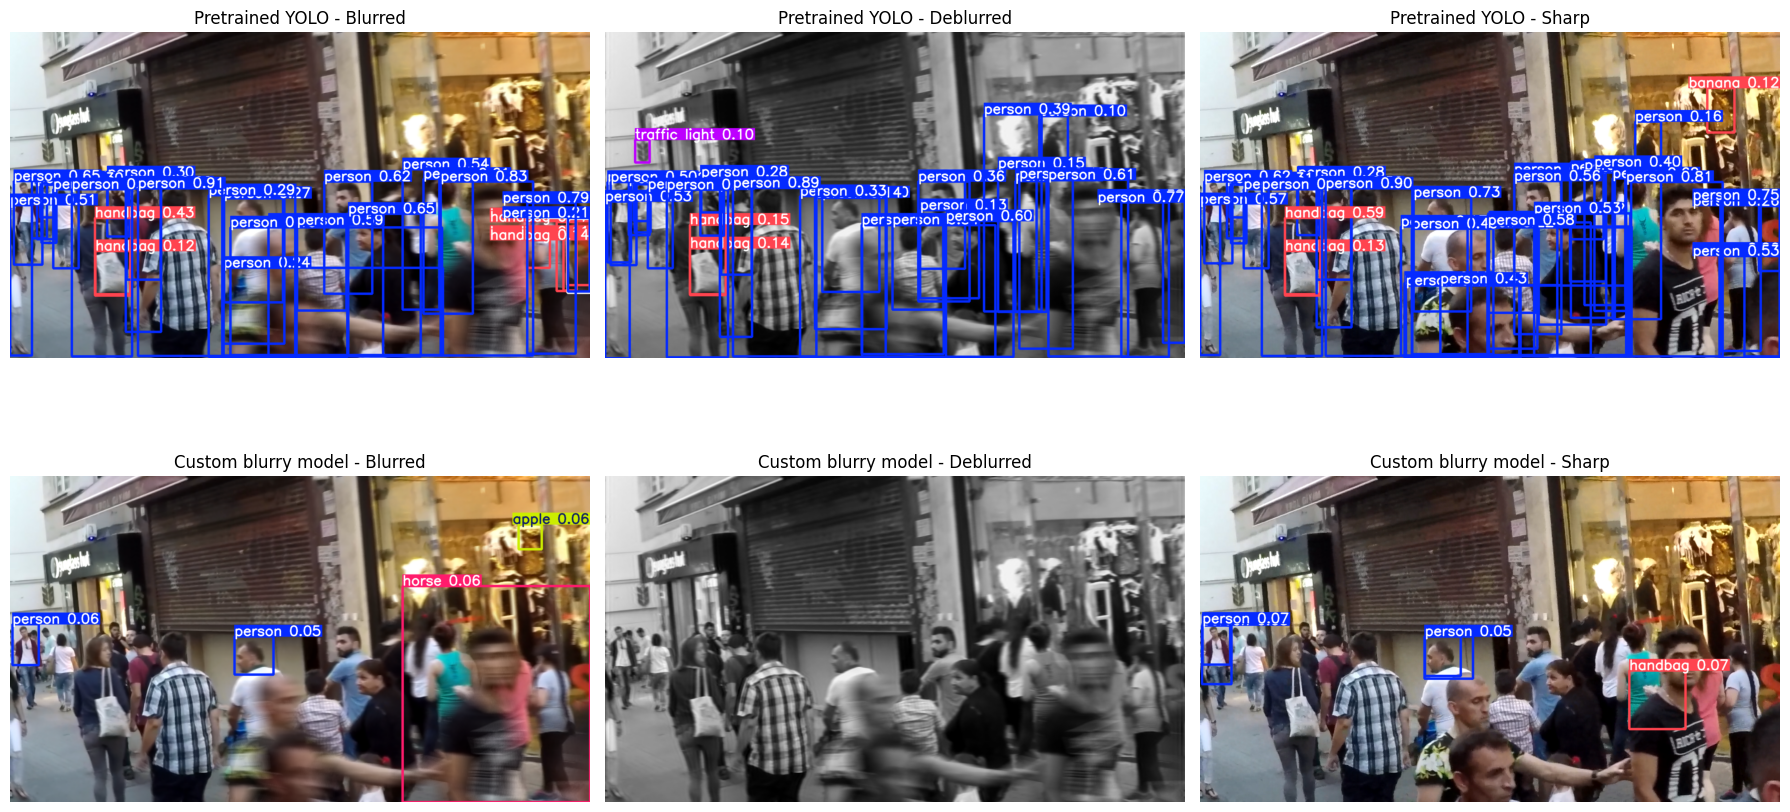

In [9]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

# Load models
pretrained = YOLO('yolov8n.pt')
custom = YOLO('/content/best.pt')

# Folders
blur_img = '/content/task5_gopro/blur1.png'
deblur_img = '/content/task5_gopro/blur1_wiener.jpg'
sharp_img = '/content/task5_gopro/sharp1.png'

triplet = [
    ('Blurred', blur_img),
    ('Deblurred', deblur_img),
    ('Sharp', sharp_img)
]

out_dir = Path('/content/task5_outputs')
out_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, (title, img_path) in enumerate(triplet):
    # Pretrained
    r1 = pretrained.predict(img_path, conf=0.10, verbose=False)[0]
    img1 = r1.plot()
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    axes[0, col].imshow(img1)
    axes[0, col].set_title(f'Pretrained YOLO - {title}')
    axes[0, col].axis('off')

    # Custom
    r2 = custom.predict(img_path, conf=0.05, verbose=False)[0]
    img2 = r2.plot()
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    axes[1, col].imshow(img2)
    axes[1, col].set_title(f'Custom blurry model - {title}')
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig(out_dir / 'task5_qualitative_comparison.png', dpi=220, bbox_inches='tight')
plt.show()